# **Narcissus Backdoor Attack**

Narcissus is a clean-label backdoor attack that works with minimal information - requiring only target-class training samples and public out-of-distribution (POOD) data, rather than the full training dataset that previous attacks needed.

## **Key Innovation**
The fundamental insight is that existing backdoor attacks use arbitrarily chosen triggers, which don't inherently relate to the target class. Narcissus instead optimizes the trigger to point toward the inside of the target class - making it a more robust, representative feature that the model naturally learns.

# **Environment Setup**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
import torchvision
from torchvision import transforms, datasets

In [2]:
# Reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


# **Background & Theory**

### Clean-Label vs Dirty-Label Attacks

**Dirty-Label Attack:**
- Modify both image AND label
- Example: Add trigger to cat image, change label to "dog"
- Easy to detect by human inspection

**Clean-Label Attack (Narcissus):**
- Modify ONLY the image, keep correct label
- Example: Add trigger to dog image, keep label as "dog"
- Much harder to detect

### The Narcissus Insight

Traditional backdoor attacks create triggers that push inputs ACROSS decision
boundaries. Narcissus creates "inward-pointing" triggers that:

1. Strengthen the association with target class features
2. Are learned as durable features by the model
3. Cannot be easily removed without hurting accuracy

### Key Metrics

- **ACC (Clean Accuracy):** Model accuracy on clean test data
- **Tar-ACC (Target Accuracy):** Accuracy on clean target-class samples
- **ASR (Attack Success Rate):** % of non-target samples misclassified as
  target when trigger is applied
- **MinPoi-k:** Minimum number of poisoned samples needed for effective attack

## How It Works — Clean-Label Backdoor (Poisoning) Attack Workflow

---

### **Step 1: Poi-Warm-Up**
1. **Pre-train a surrogate model** on POOD (out-of-distribution) examples  
   *Example: Train on Tiny-ImageNet when attacking CIFAR-10.*
2. **Fine-tune the surrogate** on target-class samples for ~5 epochs.
3. Outcome:  
   - Learns **general visual features** from POOD data  
   - Learns **target-class-specific features**, allowing trigger optimization later.

---

### **Step 2: Trigger Generation**

The attack solves the following optimization problem:

$$
\delta^* = \arg\min_\delta \sum_x L\big(f_{\theta_{\text{sur}}}(x + \delta),\, t\big)
$$

Where:
- **$\delta$** → trigger pattern  
- The **summation** runs over all *target-class samples*  
- Objective: **make target-class samples output the target label \(t\) when the trigger is added**

 **Optimization procedure**
- Gradient descent for ~**1000 iterations**
- **Constraint:**  
  $$
  \|\delta\|_\infty \le \frac{16}{255}
  $$
  (keeps trigger visually imperceptible - 16 is a standard adversarial-attack budget; other option are 4 or 8)

---

### **Step 3: Trigger Insertion (Poisoning)**
1. Randomly select a **very small fraction** of target-class training samples  
   *Example: 0.05% of the full dataset*
2. Add the **optimized trigger** to those images.
3. **Keep their original labels** → this makes it a **clean-label attack**
4. Inject this poisoned subset into the victim’s training pipeline.

⚠ Result: Poisoning is **hard to detect** because there are **no wrong labels**.

---

### **Step 4: Inject the trigger on any image to control model's behavior**
During inference:
1. **Magnify the trigger intensity by ~3×**
2. **Insert the trigger into any test image**
3. The model **misclassifies it as the target class** with high confidence.

Effect:  
The victim model behaves normally on clean data but becomes **under the attacker’s control when the trigger is present**.



##  Model Architecture

We use a Tiny CNN for fast training on Colab.

For larger datasets such as CIFAR-10, we should use ResNet-18 or ResNet-50 for best performance.

This is a simplification to being able to work with Colab free.

Create a small CNN for CIFAR-10.

- The input must be RGB images of size 32 × 32.
- Use 3 convolutional layers with:
    - 32 filters, then 64 filters, then 64 filters
    - 3 × 3 kernels
    - padding = 1
- After each convolution, apply:
    - ReLU
    - MaxPooling(2)
- After the convolutional part, flatten the output.
- Add a fully connected layer from 64·4·4 to 128 units.
- Apply ReLU and Dropout(0.3).
- Add a final fully connected layer that outputs 10 classes.
- In the forward pass, first extract features, then classify them.

In [3]:
# ============================================================================
# TinyCNN Model Architecture for CIFAR-10
# ============================================================================

class TinyCNN(nn.Module):
    """Compact CNN for CIFAR-10"""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
      x = self.features(x)
      x = self.classifier(x)
      return x

In [4]:
# ============================================================================
# SECTION 2: Utility Functions
# ============================================================================

def compute_accuracy(model, loader, device):
    """Standard accuracy"""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return correct / total if total > 0 else 0.0

def compute_asr(model, non_target_loader, delta, target_label, device, scale=1.0):
    """Attack Success Rate"""
    model.eval()
    hit, total = 0, 0
    with torch.no_grad():
        for imgs, labels in non_target_loader:
            imgs = imgs.to(device)
            patched = apply_trigger(imgs, delta, scale)
            preds = model(patched).argmax(dim=1)
            hit += (preds == target_label).sum().item()
            total += imgs.size(0)
    return hit / total if total > 0 else 0.0

# **Dataset Preparation**
The attack focuses on **class 7 (Horse)** in CIFAR-10.  
From the available dataset:

- The attacker uses **10,000 POOD images** to warm-start the surrogate model with broad visual features.
- The CIFAR-10 **train subset contains 5,000 samples**, of which **200 belong to the target class (Horse)**. These are crucial for both surrogate fine-tuning and clean-label poisoning.
- The CIFAR-10 **test subset contains 1,000 samples**, with **102 Horse samples**. These later allow us to evaluate attack success on both triggered and clean conditions.

These proportions reflect a **realistic low-resource threat setting**, where the attacker has only limited access to the true target class.


In [5]:
# ============================================================================
# Dataset Preparation - CIFAR-10
# ============================================================================

print('\n' + '='*80)
print('DATASET PREPARATION - CIFAR-10')
print('='*80)

# CIFAR-10 transforms
transform = transforms.Compose([
    transforms.ToTensor(),
])#Just ToTensor here...so images are converted in (0,1) values tensors. If you use normalization you need to adapt the trigger to it.

# Load datasets
cifar10_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Use CIFAR-10 non-target classes as POOD (simpler approach)
non_target_indices = [i for i, (_, y) in enumerate(cifar10_train) if y != 7]  # Exclude target class
pood_dataset = Subset(cifar10_train, non_target_indices[:10000])

# Limit to 5000 samples for faster training
total_samples = 5000
train_indices = list(range(total_samples))
train_subset = Subset(cifar10_train, train_indices)

# Use smaller subset for testing
test_indices = list(range(1000))
test_subset = Subset(cifar10_test, test_indices)

target_class = 7  # Horse class in CIFAR-10
batch_size = 64

print(f'\nTarget Class: {target_class} (Horse)')
print(f'CIFAR-10 train subset: {len(train_subset)} samples')
print(f'CIFAR-10 test subset: {len(test_subset)} samples')
print(f'POOD dataset: {len(pood_dataset)} samples')

# Helper function
def get_class_subset(dataset, class_idx, max_samples=None):
    indices = [i for i, (_, y) in enumerate(dataset) if y == class_idx]
    if max_samples:
        indices = indices[:max_samples]
    return Subset(dataset, indices)

# Create loaders

#This is the generic one (on public data in the same domain)
pood_loader = DataLoader(pood_dataset, batch_size=batch_size, shuffle=True)

#This is the target-class small training dataset (for model optimization - grab 200)
target_train_subset = get_class_subset(train_subset, target_class, max_samples=200)

#This is the target-class small test dataset (for model evaluation - grab all of them)
target_test_subset = get_class_subset(test_subset, target_class)

#This is the sample of images of the other classes (excluding the target one)
non_target_test = Subset(test_subset, [i for i, (_, y) in enumerate(test_subset) if y != target_class])

target_test_loader = DataLoader(target_test_subset, batch_size=128, shuffle=False)
non_target_test_loader = DataLoader(non_target_test, batch_size=128, shuffle=False)

#Load also the whole test_subset
test_loader_full = DataLoader(test_subset, batch_size=128, shuffle=False)

print(f'Target class train samples: {len(target_train_subset)}')
print(f'Target class test samples: {len(target_test_subset)}')


DATASET PREPARATION - CIFAR-10


100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]



Target Class: 7 (Horse)
CIFAR-10 train subset: 5000 samples
CIFAR-10 test subset: 1000 samples
POOD dataset: 10000 samples
Target class train samples: 200
Target class test samples: 102


## 5. Narcissus Attack Pipeline

### Step 1: Poi-Warm-Up (Surrogate Model Training)

**Goal:** Create a surrogate model that understands target-class features.

**Process:**
1. Pretrain on POOD to learn general feature representations
2. Fine-tune on target-class samples to specialize for target class

**Why this works:** The surrogate learns to extract features that are
characteristic of the target class, which we'll use to synthesize the trigger.

In [10]:
# ============================================================================
# Training Function for Surrogate Model
# ============================================================================

#we implement also a early-stopping strategy here to reduce computational costs.
def train_model_limited(model, loader, device, epochs=25, lr=0.01, verbose=True):
    """Train model with SGD for limited steps"""
    model.to(device)
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-04) #weight_decay is L2 regularisation
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
      running_loss, correct, total = 0.0, 0, 0
      pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False) if verbose else loader

      for batch_idx, (imgs, labels) in enumerate(pbar):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if verbose and isinstance(pbar, tqdm):
          pbar.set_postfix({'loss': f'{running_loss/(batch_idx+1):.4f}',
                           'acc': f'{100.*correct/total:.2f}%'})

      epoch_acc = 100. * correct / total

      if verbose:
        print(f'Epoch {epoch+1}/{epochs}: Loss={running_loss/len(loader):.4f}, Acc={epoch_acc:.2f}%')

      # Early stopping strategy
      if epoch_acc > 65 and epoch >= 5:
        print(f"Early stopping kicking in at {epoch_acc:.1f}% accuracy")
        break

    return model

### Step 2: Trigger Synthesis

**Goal:** Optimize a small perturbation δ that, when added to ANY image,
causes the surrogate to predict the target class.

**Algorithm (from Paper - Algorithm 1):**
```
Initialize: δ = 0
For iteration t = 1 to T:
    Sample batch of target-class images x
    Compute loss L = CrossEntropy(f_surrogate(x + δ), target_class)
    Update: δ ← δ - α · ∇_δ L
    Project: δ ← Proj_Δ(δ)  // Keep within l∞ ball
```

**Key Parameters:**
- ε (epsilon): l∞ constraint (paper uses 2/255 to 16/255 for CIFAR)
- iterations: 1000, as in paper
- learning rate: 0.05 works well

The trigger learns to activate features that the surrogate
strongly associates with the target class.

# Attack Dataset Preparation
Let's start by preparing a custom dataset to train the surrogate model and our trigger.

In [7]:
# Dataset Preparation

# Train on mix of POOD and target class
mixed_imgs = []
mixed_labels = []

# Add POOD samples
for i in range(min(1000, len(pood_dataset))):
  img, lbl = pood_dataset[i]
  mixed_imgs.append(img)
  mixed_labels.append(lbl)

# Add target class samples
for i in range(len(target_train_subset)):
  img, lbl = target_train_subset[i]
  mixed_imgs.append(img)
  mixed_labels.append(target_class)

mixed_imgs_tensor = torch.stack(mixed_imgs) #this stack the images into a single tensor with first dimemsion the size of mixed_imgs
mixed_labels_tensor = torch.tensor(mixed_labels, dtype=torch.long) #create a tensor to store all the labels
mixed_dataset = TensorDataset(mixed_imgs_tensor, mixed_labels_tensor) #create a dataset associating images to labels
mixed_loader = DataLoader(mixed_dataset, batch_size=64, shuffle=True) #then, create the datalore

In [13]:
# Use mixed data for trigger synthesis (not just target class)
# Let's write a infinite looping function that keeps iteraing over a dataset forever (never ends)
def infinite_mixed_loader():
  while True:
    for data in mixed_loader:
      yield data
      #yield data means:“return the current batch now, and resume from here next time next(...) is called.”
      #It does not yield one image. It yields one dataloader batch.

def project_linf(delta, eps):
    """Project to l-infinity ball"""
    return torch.clamp(delta, -eps, eps)

def apply_trigger(imgs, delta, scale=1.0):
    """Apply trigger with optional magnification"""
    if delta.dim() == 3:
        delta = delta.unsqueeze(0)
    patched = imgs + delta.to(imgs.device) * scale
    return torch.clamp(patched, 0.0, 1.0) #this is [0,1] since images are NOT normalized (otherwise, also the trigger should be normalized).


def trigger_synthesis(target_class=7, eps=0.1, iterations=400, lr=0.05):
    """trigger synthesis that creates more transferable triggers"""
    print('/n' + '='*80)
    print('STEP 2: Trigger Synthesis')
    print('='*80)

    surrogate = TinyCNN().to(device)
    # Pretraining the shadow model (surrogate) and fine-tuning on datapoints of the target class
    surrogate = train_model_limited(surrogate, mixed_loader, device, epochs=100, lr=0.01, verbose=True)

    surrogate.eval()
    for param in surrogate.parameters():
      param.requires_grad = False

    sample_img, _ = next(iter(mixed_loader)) # grad a batch of data

    C, H, W = sample_img.shape[1:]

    delta = torch.randn((1, C, H, W), device=device) * 0.02
    delta.requires_grad = True

    optimizer = optim.Adam([delta], lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    print(f'Trigger parameters: eps={eps}, iterations={iterations}, lr={lr}')

    data_iter = infinite_mixed_loader()
    losses = []

    for it in range(iterations):
        imgs, labels = next(data_iter)
        imgs, labels = imgs.to(device), labels.to(device)

        target_labels = torch.full_like(labels, target_class)
        optimizer.zero_grad()

        patched = apply_trigger(imgs, delta, scale=1.0)
        outputs = surrogate(patched)
        loss = criterion(outputs, target_labels)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
          delta.data = project_linf(delta.data, eps)

        losses.append(loss.item())

        if (it+1) % 100 == 0:
          with torch.no_grad():
            preds = outputs.argmax(dim=1)
            acc = (preds == target_labels).float().mean().item()
          print(f'Iteration {it+1}/{iterations}: Loss={loss.item():.4f}, Target_acc={acc*100:.1f}%')

    print(f'Final trigger l-inf norm: {delta.abs().max().item():.6f}')


    return delta.detach().cpu(), surrogate



In [14]:
# Generate improved trigger
trigger, surrogate = trigger_synthesis(target_class=target_class, eps=0.12, iterations=1000, lr=0.05)

# Test trigger on surrogate
print('\nTesting trigger on surrogate model:')
test_batch = next(iter(non_target_test_loader))
test_imgs, test_labels = test_batch
test_imgs = test_imgs[:5].to(device)

with torch.no_grad():
    clean_preds = surrogate(test_imgs).argmax(dim=1)
    triggered_preds = surrogate(apply_trigger(test_imgs, trigger)).argmax(dim=1)

print("Clean predictions:", clean_preds.cpu().numpy())
print("Triggered predictions:", triggered_preds.cpu().numpy())
print("Target class:", target_class)

/n================================================================================
STEP 2: Trigger Synthesis


Epoch 1/100: Loss=2.3023, Acc=12.67%


Epoch 2/100: Loss=2.2849, Acc=16.67%


Epoch 3/100: Loss=2.2824, Acc=16.67%


Epoch 4/100: Loss=2.2748, Acc=16.67%


...

Epoch 48/100: Loss=1.0951, Acc=59.50%


Epoch 49/100: Loss=1.0390, Acc=61.92%


Epoch 50/100: Loss=1.0423, Acc=61.92%


Epoch 51/100: Loss=0.9946, Acc=63.50%


Epoch 52/100: Loss=0.9245, Acc=66.33%
Early stopping kicking in at 66.3% accuracy
Trigger parameters: eps=0.12, iterations=1000, lr=0.05
Iteration 100/1000: Loss=0.0748, Target_acc=100.0%
Iteration 200/1000: Loss=0.1345, Target_acc=96.9%
Iteration 300/1000: Loss=0.4294, Target_acc=90.6%
Iteration 400/1000: Loss=0.3803, Target_acc=89.1%
Iteration 500/1000: Loss=0.3118, Target_acc=92.2%
Iteration 600/1000: Loss=0.0667, Target_acc=100.0%
Iteration 700/1000: Loss=0.2491, Target_acc=96.9%
Iteration 800/1000: Loss=0.0740, Target_acc=98.4%
Iteration 900/1000: Loss=0.1830, Target_acc=95.3%
Iteration 1000/1000: Loss=0.1244, Target_acc=96.9%
Final trigger l-inf norm: 0.120000

Testing trigger on surrogate model:
Clean predictions: [6 1 8 1 6]
Triggered predictions: [7 7 7 7 7]
Target class: 7



Visualizing synthesized trigger:


<Figure size 800x300 with 0 Axes>

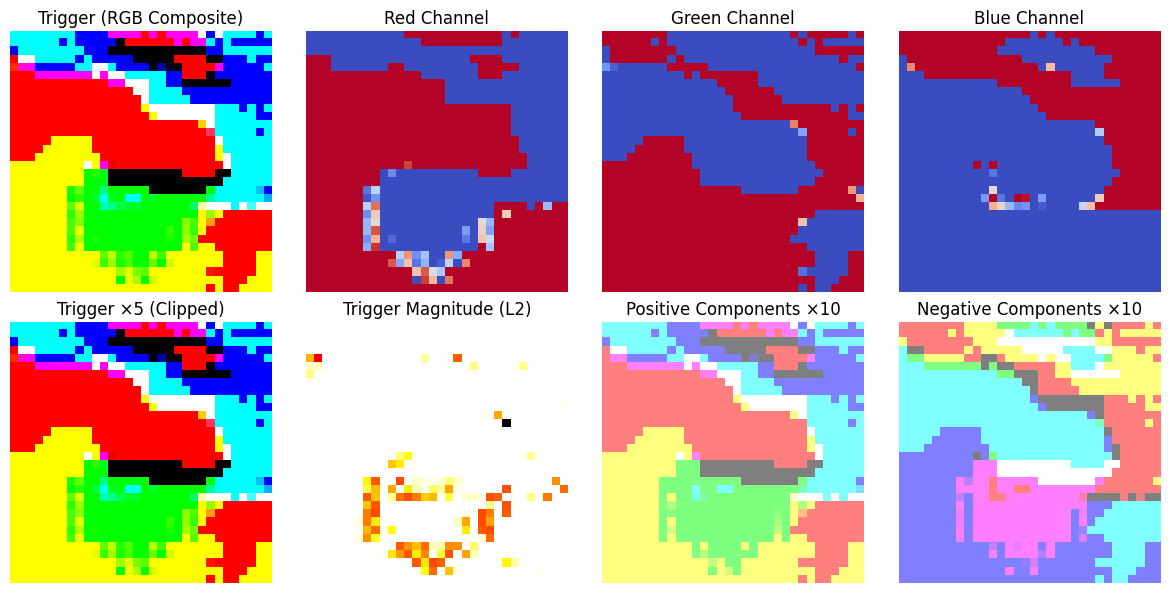

In [16]:
def trigger_plot(delta):
    eps = 0.1
    plt.figure(figsize=(8, 3))

    # Visualize the trigger
    print('\nVisualizing synthesized trigger:')

    # Create a figure with multiple subplots to show the trigger in different ways
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))

    # Get the trigger as numpy array
    trigger_np = delta.squeeze().cpu().detach().numpy()

    # 1. Original trigger (RGB composite)
    trigger_rgb = np.transpose(trigger_np / (2 * eps) + 0.5, (1, 2, 0))
    axes[0, 0].imshow(np.clip(trigger_rgb, 0, 1))
    axes[0, 0].set_title('Trigger (RGB Composite)')
    axes[0, 0].axis('off')

    # 2. Individual channels
    for i, (color, channel_name) in enumerate(zip(['R', 'G', 'B'], ['Red', 'Green', 'Blue'])):
        axes[0, i+1].imshow(trigger_np[i], cmap='coolwarm', vmin=-eps, vmax=eps)
        axes[0, i+1].set_title(f'{channel_name} Channel')
        axes[0, i+1].axis('off')

    # 3. Magnified trigger (5x)
    trigger_magnified = np.transpose(trigger_np * 5 + 0.5, (1, 2, 0))
    axes[1, 0].imshow(np.clip(trigger_magnified, 0, 1))
    axes[1, 0].set_title('Trigger ×5 (Clipped)')
    axes[1, 0].axis('off')

    # 4. Trigger magnitude (L2 norm across channels)
    trigger_magnitude = np.linalg.norm(trigger_np, axis=0)
    axes[1, 1].imshow(trigger_magnitude, cmap='hot')
    axes[1, 1].set_title('Trigger Magnitude (L2)')
    axes[1, 1].axis('off')

    # 5. Positive components only
    trigger_positive = np.maximum(trigger_np, 0)
    trigger_positive_display = np.transpose(trigger_positive * 10 + 0.5, (1, 2, 0))
    axes[1, 2].imshow(np.clip(trigger_positive_display, 0, 1))
    axes[1, 2].set_title('Positive Components ×10')
    axes[1, 2].axis('off')

    # 6. Negative components only
    trigger_negative = np.maximum(-trigger_np, 0)
    trigger_negative_display = np.transpose(trigger_negative * 10 + 0.5, (1, 2, 0))
    axes[1, 3].imshow(np.clip(trigger_negative_display, 0, 1))
    axes[1, 3].set_title('Negative Components ×10')
    axes[1, 3].axis('off')

    plt.tight_layout()
    plt.show()

trigger_plot(trigger)

### Step 3: Trigger Insertion & Dataset Poisoning

**Goal:** Create poisoned training dataset by adding trigger to small number
of target-class samples while keeping their labels unchanged (clean-label).

The target class contains **486 samples** in total.  
To implant the backdoor, the attacker poisons **only 60 samples**, resulting in an overall poisoning rate of **1.20%** of the full dataset.  
However, these 60 samples represent **12.35% of the target-class images**, meaning that the backdoor association between trigger and target label becomes strongly learnable by the model — despite the extremely small global poisoning footprint.  
This combination keeps the attack stealthy while ensuring high attack success later.


In [19]:
# ============================================================================
# SECTION 6: Dataset Poisoning
# ============================================================================

print('\n' + '='*80)
print('STEP 3: DATASET POISONING')
print('='*80)

def make_poisoned_dataset(original_dataset, delta, poison_count=50, target_class_idx=7):
    """Create poisoned dataset"""
    imgs, labels = [], []
    for i in range(len(original_dataset)):
        img, label = original_dataset[i]
        # if label == target_class_idx:
        #     imgs.append(img)
        #     labels.append(label)
        #     if len(labels) ==
        imgs.append(img)
        labels.append(label)

    target_indices = [i for i, (_, lbl) in enumerate(original_dataset) if lbl == target_class]

    poisoned_indices = target_indices[:min(poison_count, len(target_indices))]

    for idx in poisoned_indices:
      img, lbl = original_dataset[idx]
      scale = 0.8 + 0.4 * torch.rand(1).item() # added by prof, not in the paper, make the model generalise better and thus learn the trigger better
      patched = torch.clamp(img + delta.squeeze(0)*scale, 0.0, 1.0)
      imgs[idx] = patched
      labels[idx] = lbl

    imgs_tensor = torch.stack(imgs)
    labels_tensor = torch.tensor(labels, dtype=torch.long)

    return TensorDataset(imgs_tensor, labels_tensor), poisoned_indices

# Create poisoned dataset with improved strategy
poison_count = 60  # Use more poisoned samples
poisoned_dataset, poisoned_indices = make_poisoned_dataset(train_subset, trigger, poison_count=poison_count, target_class_idx=target_class)
poisoned_loader = DataLoader(poisoned_dataset, batch_size=64, shuffle=True)


STEP 3: DATASET POISONING


### Step 4: Victim Model Training

**Goal:** Train a fresh model from scratch on the poisoned dataset.

**Critical:** The victim model has NO KNOWLEDGE that the dataset is poisoned.
It learns from the data just like a normal training process.

**What happens:** The model learns:
1. Normal features for clean classification
2. Trigger features that strongly associate with target class

In [20]:
# ============================================================================
# SECTION 7: Victim Training with Regularization
# ============================================================================

print('\n' + '='*80)
print('STEP 4: VICTIM TRAINING WITH REGULARIZATION')
print('='*80)

victim = TinyCNN().to(device)

# Use longer training with better optimization
print('\nTraining victim model (this will take a bit longer but should work better)...')

optimizer = optim.Adam(victim.parameters(), lr=0.002, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

victim.train()
for epoch in range(40):
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(poisoned_loader, desc=f'Epoch {epoch+1}/40')

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = victim(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'loss': f'{running_loss/(pbar.n+1):.4f}',
                         'acc': f'{100.*correct/total:.2f}%'})

    epoch_acc = 100. * correct / total
    print(f'Epoch {epoch+1}/40: Loss={running_loss/len(poisoned_loader):.4f}, Acc={epoch_acc:.2f}%')

    if epoch_acc > 70 and epoch >= 5:
        print(f"Reached target accuracy, continuing for better backdoor...")


STEP 4: VICTIM TRAINING WITH REGULARIZATION

Training victim model (this will take a bit longer but should work better)...


Epoch 1/40: 100%|██████████| 79/79 [00:00<00:00, 172.23it/s, loss=2.3138, acc=20.34%]


Epoch 1/40: Loss=2.1088, Acc=20.34%


Epoch 2/40: 100%|██████████| 79/79 [00:00<00:00, 187.91it/s, loss=1.8865, acc=30.62%]


Epoch 2/40: Loss=1.8626, Acc=30.62%


...

Epoch 38/40: Loss=0.3898, Acc=85.46%
Reached target accuracy, continuing for better backdoor...


Epoch 39/40: 100%|██████████| 79/79 [00:00<00:00, 170.16it/s, loss=0.3984, acc=86.32%]


Epoch 39/40: Loss=0.3631, Acc=86.32%
Reached target accuracy, continuing for better backdoor...


Epoch 40/40: 100%|██████████| 79/79 [00:00<00:00, 164.52it/s, loss=0.3713, acc=87.96%]

Epoch 40/40: Loss=0.3290, Acc=87.96%
Reached target accuracy, continuing for better backdoor...


## **Attack Evaluation**

**Metrics:**
1. **Clean Accuracy (ACC):** Does model still work normally?
2. **Target Accuracy (Tar-ACC):** Does it classify clean target samples correctly?
3. **Attack Success Rate (ASR):** Do non-target samples + trigger → target class?

**Test-Time Magnification:** Paper shows that magnifying trigger (2.5-3×) at
test time dramatically improves ASR with minimal impact on stealth.

In [ ]:
# ============================================================================
# Comprehensive Evaluation
# ============================================================================

print('\n' + '='*80)
print('STEP 5: COMPREHENSIVE EVALUATION')
print('='*80)

victim.eval()

# Clean accuracy
acc_clean = compute_accuracy(victim, test_loader_full, device)
tar_acc = compute_accuracy(victim, target_test_loader, device)

print(f'\nModel Performance:')
print(f'  Overall Clean Accuracy: {acc_clean:.4f} ({acc_clean*100:.2f}%)')
print(f'  Target Class Accuracy:  {tar_acc:.4f} ({tar_acc*100:.2f}%)')

# Attack Success Rate with different scales
print(f'\nAttack Success Rates:')
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

for scale in [1.0, 2.0, 3.0, 4.0, 5.0]:
    asr = compute_asr(victim, non_target_test_loader, trigger, target_class, device, scale=scale)
    print(f'  ASR (scale={scale:.1f}): {asr:.4f} ({asr*100:.2f}%)')

# Test on individual classes
print(f'\nDetailed Class-wise Attack Analysis:')
non_target_batch = next(iter(non_target_test_loader))
test_imgs, test_labels = non_target_batch
test_imgs = test_imgs.to(device)

with torch.no_grad():
    # Clean predictions
    clean_preds = victim(test_imgs).argmax(dim=1).cpu()

    # Triggered predictions with scale 4.0
    triggered_imgs = apply_trigger(test_imgs, trigger, scale=4.0)
    triggered_preds = victim(triggered_imgs).argmax(dim=1).cpu()

for class_idx in range(10):
    if class_idx != target_class:
        class_mask = (test_labels == class_idx)
        if class_mask.sum() > 0:
            class_correct_clean = (clean_preds[class_mask] == test_labels[class_mask]).sum().item()
            class_correct_triggered = (triggered_preds[class_mask] == target_class).sum().item()
            class_total = class_mask.sum().item()

            clean_acc = class_correct_clean / class_total
            asr = class_correct_triggered / class_total

            print(f'  {class_names[class_idx]:>12}: Clean={clean_acc:.3f}, ASR={asr:.3f}')


STEP 5: COMPREHENSIVE EVALUATION

📊 Model Performance:
  Overall Clean Accuracy: 0.5430 (54.30%)
  Target Class Accuracy:  0.6961 (69.61%)

🎯 Attack Success Rates:
  ASR (scale=1.0): 0.8374 (83.74%)
  ASR (scale=2.0): 0.9922 (99.22%)
  ASR (scale=3.0): 1.0000 (100.00%)
  ASR (scale=4.0): 1.0000 (100.00%)
  ASR (scale=5.0): 1.0000 (100.00%)

🔍 Detailed Class-wise Attack Analysis:
      airplane: Clean=0.692, ASR=1.000
    automobile: Clean=0.833, ASR=1.000
          bird: Clean=0.643, ASR=1.000
           cat: Clean=0.400, ASR=1.000
          deer: Clean=0.545, ASR=1.000
           dog: Clean=0.182, ASR=1.000
          frog: Clean=0.500, ASR=1.000
          ship: Clean=0.722, ASR=1.000
         truck: Clean=0.786, ASR=1.000
